# ساختِ پورتفوی بهینه روی ۶ سهم — با ورودیِ پیش‌بینی‌های مدلِ Ensemble
### Portfolio Construction using Black-Litterman + HRP (TSE Covered-Call Universe)

**ورودی:** خروجی‌های واقعیِ نوت‌بوکِ `price_at_maturity_prediction.ipynb`
(فایل‌های `data/price_at_maturity_predictions_<asset>.csv` و
`data/price_at_maturity_recommended_models.csv`) — هیچ پیش‌بینیِ جدیدی در
این‌جا ساخته نمی‌شود؛ فقط از نتایجِ همان کار برای ساختِ پورتفو استفاده می‌شود.

**خروجی:** وزنِ هر یک از ۶ سهم در پورتفو، طوری که مجموعِ وزن‌ها دقیقاً ۱ شود.

## چرا این روش — نه یک بهینه‌سازیِ سادهٔ Markowitz

اگر مستقیماً از پیش‌بینی‌های خامِ مدل به‌عنوانِ «بازدهِ موردانتظار» در یک
بهینه‌سازیِ Markowitz استفاده کنیم، نتیجه تقریباً همیشه یک پورتفویِ ناپایدار و
بیش‌ازحد متمرکز است — این دقیقاً همان مشکلِ معروفی است که **Michaud (1989)**
آن را «**Markowitz Optimization Enigma**» نامید: بهینه‌سازیِ میانگین-واریانس به
خطای برآوردِ بازدهِ موردانتظار به‌شدت حساس است و آن را در وزن‌ها تشدید می‌کند.
راه‌حلِ استانداردِ صنعت (که در این نوت‌بوک پیاده شده):

| مرحله | مشکل | راه‌حلِ حرفه‌ای (با استناد) |
|---|---|---|
| کوواریانسِ ریسک | کوواریانسِ نمونه با تعدادِ کمِ دارایی (۶ سهم) نویزی و ناپایدار است | **Ledoit-Wolf Shrinkage Covariance** (Ledoit & Wolf, 2004) |
| بازدهِ موردانتظار | استفادهٔ مستقیم از پیش‌بینیِ خامِ ML → تمرکزِ افراطی (Michaud enigma) | **مدلِ Black-Litterman** (Black & Litterman, 1992): پیش‌بینیِ ML به‌عنوانِ «دیدگاه» (View) با بازدهِ تعادلیِ بازار (Equilibrium Return) ترکیب می‌شود؛ هرچه مدل در آن سهم نامطمئن‌تر بوده (RMSE بالاتر در نوت‌بوکِ پیش‌بینی)، وزنِ کمتری به دیدگاهِ ML آن سهم داده می‌شود. |
| بهینه‌سازیِ نهایی | Max-Sharpe بدونِ محدودیت → راه‌حلِ گوشه‌ای (۱۰۰٪ روی یک سهم) | محدودیتِ عملیِ صنعتی: هر سهم بینِ ۵٪ تا ۳۰٪ (بدونِ فروشِ استقراضی، مناسبِ صاحبِ سهمی که می‌خواهد کاورد کال هم بنویسد). |
| اعتبارسنجیِ روش | یک روشِ تکی ممکن است تصادفی خوب/بد به‌نظر برسد | مقایسه با **Hierarchical Risk Parity** (López de Prado, 2016 — همان نویسندهٔ Purged Cross-Validation که در نوت‌بوکِ پیش‌بینی استفاده شده)، Minimum-Variance، Equal-Weight، و وزنِ متناسب با ارزشِ معاملات، تا مشخص شود Black-Litterman واقعاً افزوده‌ای دارد یا نه. |

این ترکیب (Black-Litterman + Shrinkage Covariance + محدودیتِ وزن + مقایسه با HRP)
دقیقاً همان مجموعه‌روشی است که در ادبیاتِ حرفه‌ایِ مدیریتِ دارایی (Idzorek 2005؛
Attilio Meucci's *Risk and Asset Allocation*، ۲۰۰۵) به‌عنوانِ استانداردِ عملی
معرفی می‌شود — نه یک بهینه‌سازیِ آموزشیِ ساده.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_NAMES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
RISK_FREE_RATE = 0.20   # همان فرضِ نرخِ بدونِ ریسکِ covered_call_strategy.py
COV_WINDOW = 504        # ~۲ سالِ معاملاتیِ اخیر برای برآوردِ کوواریانس (رژیمِ نوسانِ فعلی، نه کلِ ۱۵ سال)
TAU = 0.05              # پارامترِ استانداردِ عدمِ‌قطعیتِ Black-Litterman (He & Litterman, 1999)
W_MIN, W_MAX = 0.05, 0.30  # محدودیتِ وزنِ هر سهم

CORP_ACTION_THRESHOLD = 0.25

print("✅ Ready")

✅ Ready


## ۱) بارگذاریِ قیمت‌ها (همان تعدیلِ وقایعِ شرکتیِ نوت‌بوکِ پیش‌بینی)

In [2]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0 and abs(c1 / c0 - 1.0) > threshold:
            cum *= c1 / c0
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df


processed = {}
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df = adjust_corporate_actions(df)
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    processed[name] = df.loc['2010-01-01':]
    print(f"  {name}: {len(processed[name])} روز | آخرین قیمت = {processed[name]['close'].iloc[-1]:,.0f} تومان")

  Fameli: 3448 روز | آخرین قیمت = 9,720 تومان
  Fulad: 3424 روز | آخرین قیمت = 4,131 تومان
  IranKhodro: 3296 روز | آخرین قیمت = 3,868 تومان
  Khgostar: 3405 روز | آخرین قیمت = 5,508 تومان
  Shapna: 2969 روز | آخرین قیمت = 3,505 تومان
  VebMellat: 3215 روز | آخرین قیمت = 2,748 تومان


## ۲) کوواریانسِ ریسک — Ledoit-Wolf Shrinkage روی ۲ سالِ اخیر

به‌جای کوواریانسِ نمونه‌ی خام (که با فقط ۶ دارایی نویزی و بدشرطی‌شده است)، از
تخمین‌گرِ **Ledoit-Wolf** استفاده می‌شود — کوواریانسِ نمونه را به‌سمتِ یک هدفِ
ساختاریافته (مضربی از ماتریسِ همانی) می‌کشد؛ ضریبِ Shrinkage به‌صورتِ خودکار و
بهینه از خودِ داده تخمین زده می‌شود (نه یک عددِ دلبخواهی).

بازه‌ی برآوردِ کوواریانس: 2022-09-07 تا 2025-03-12 (504 روز)


شدتِ Shrinkage (خودکار، از داده تخمین زده شده): 0.021

نوسانِ سالانه‌شده به‌ازای هر سهم:
  Fameli: 34.6%
  Fulad: 30.9%
  IranKhodro: 36.8%
  Khgostar: 43.0%
  Shapna: 36.8%
  VebMellat: 33.3%


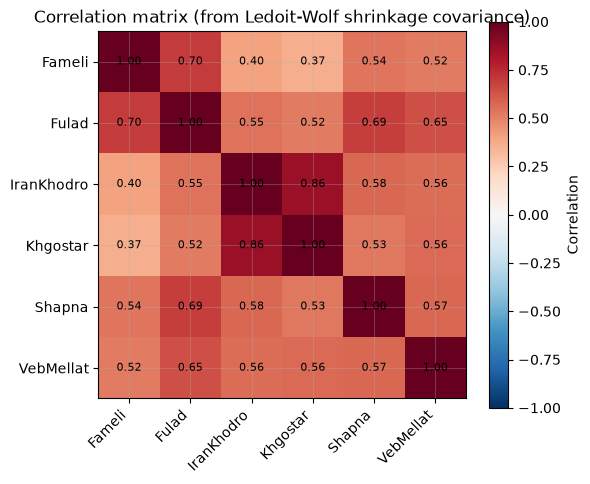

In [3]:
ret_wide = pd.DataFrame({name: np.log(df['close'] / df['close'].shift(1)) for name, df in processed.items()})
ret_recent = ret_wide.dropna().iloc[-COV_WINDOW:]
print(f"بازه‌ی برآوردِ کوواریانس: {ret_recent.index.min().date()} تا {ret_recent.index.max().date()} ({len(ret_recent)} روز)")

lw = LedoitWolf().fit(ret_recent.values)
Sigma_ann = lw.covariance_ * 252
print(f"شدتِ Shrinkage (خودکار، از داده تخمین زده شده): {lw.shrinkage_:.3f}")

vol_ann = np.sqrt(np.diag(Sigma_ann))
corr_ann = Sigma_ann / np.outer(vol_ann, vol_ann)
print("\nنوسانِ سالانه‌شده به‌ازای هر سهم:")
for n, v in zip(ASSET_NAMES, vol_ann):
    print(f"  {n}: {v:.1%}")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_ann, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(ASSET_NAMES))); ax.set_xticklabels(ASSET_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(ASSET_NAMES))); ax.set_yticklabels(ASSET_NAMES)
for i in range(len(ASSET_NAMES)):
    for j in range(len(ASSET_NAMES)):
        ax.text(j, i, f'{corr_ann[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, label='Correlation')
ax.set_title('Correlation matrix (from Ledoit-Wolf shrinkage covariance)')
plt.tight_layout()
plt.show()

## ۳) بازدهِ تعادلیِ بازار (Equilibrium Prior) — Reverse Optimization

نقطه‌ی شروعِ Black-Litterman، بازدهِ موردانتظاری است که اگر بازار در تعادل
باشد، از وزنِ فعلیِ هر سهم استخراج می‌شود (نه برعکس). چون داده‌ی ارزشِ بازار
(Market Cap) در دسترس نیست، از **میانگینِ ارزشِ معاملاتِ روزانه** (ستونِ
`value` در دادهٔ TSETMC — یک داده‌ی واقعی، نه فرضی) به‌عنوانِ نماینده‌ی
اندازه/اهمیتِ نسبیِ هر سهم استفاده می‌شود. رابطه‌ی معکوس‌سازی:
$\Pi = \delta \, \Sigma \, w_{mkt}$ که در آن $\delta$ ضریبِ ریسک‌گریزیِ بازار
است (مقدارِ استانداردِ کتاب‌های مرجع: ۲.۵).

In [4]:
DELTA = 2.5
avg_value = pd.Series({name: df['value'].iloc[-COV_WINDOW:].mean() for name, df in processed.items()})
w_mkt = (avg_value / avg_value.sum()).reindex(ASSET_NAMES).values
Pi = DELTA * Sigma_ann @ w_mkt

prior_df = pd.DataFrame({'Asset': ASSET_NAMES, 'TradedValue_Weight': w_mkt, 'Equilibrium_Return': Pi})
display(prior_df.style.format({'TradedValue_Weight': '{:.1%}', 'Equilibrium_Return': '{:.1%}'}))

,Asset,TradedValue_Weight,Equilibrium_Return
0,Fameli,12.2%,17.0%
1,Fulad,16.6%,18.3%
2,IranKhodro,20.6%,22.4%
3,Khgostar,13.5%,25.4%
4,Shapna,12.1%,20.7%
5,VebMellat,25.1%,19.9%


## ۴) دیدگاه‌ها (Views) — مستقیماً از خروجیِ مدلِ Ensemble

برایِ هر سهم، دو عدد از فایل‌های نوت‌بوکِ پیش‌بینی خوانده می‌شود (هیچ محاسبه‌ی
جدیدی روی مدل انجام نمی‌شود):

- **دیدگاه ($Q$)**: میانگینِ بازدهِ H‌روزه‌ای که مدلِ Ensemble طیِ کلِ دوره‌ی
  Test پیش‌بینی کرده، سالانه‌شده.
- **عدمِ‌قطعیتِ دیدگاه ($\Omega$)**: از RMSEِ واقعیِ همان مدل روی Test
  (`price_at_maturity_results.csv`) — هرچه مدل برایِ یک سهم نامطمئن‌تر بوده
  (RMSE بالاتر)، آن دیدگاه در فرمولِ Black-Litterman وزنِ کمتری می‌گیرد. این
  دقیقاً پیاده‌سازیِ اصلِ **Idzorek (2005)** برایِ تبدیلِ «اطمینانِ تحلیل‌گر»
  به $\Omega$ است — با این تفاوت که این‌جا «اطمینان» یک عددِ ساختگی نیست،
  بلکه مستقیماً از خطای اندازه‌گیری‌شده‌ی مدل می‌آید.

In [5]:
rec = pd.read_csv(DATA_DIR + 'price_at_maturity_recommended_models.csv').set_index('Asset')
results = pd.read_csv(DATA_DIR + 'price_at_maturity_results.csv')

Q, omega_diag, horizons = [], [], []
for name in ASSET_NAMES:
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv')
    H = int(rec.loc[name, 'Horizon_days'])
    horizons.append(H)
    logret_view = np.log(dfp['pred_ensemble'] / dfp['actual_price'])
    Q.append(logret_view.mean() * 252 / H)
    ens_row = results[(results.Asset == name) & (results.Model == 'Ensemble')].iloc[0]
    omega_diag.append((ens_row['RMSE_logret'] * np.sqrt(252 / H)) ** 2)

Q = np.array(Q)
Omega = np.diag(omega_diag)
views_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Horizon_days': horizons,
                          'View_Return_Annualized': Q, 'View_StdDev_Annualized': np.sqrt(omega_diag)})
display(views_df.style.format({'View_Return_Annualized': '{:.1%}', 'View_StdDev_Annualized': '{:.1%}'}))

,Asset,Horizon_days,View_Return_Annualized,View_StdDev_Annualized
0,Fameli,10,-2.9%,40.4%
1,Fulad,10,10.5%,37.4%
2,IranKhodro,10,0.2%,49.0%
3,Khgostar,10,16.0%,57.1%
4,Shapna,10,61.1%,47.9%
5,VebMellat,20,-1.3%,46.0%


## ۵) پسینِ Black-Litterman

فرمولِ استانداردِ Black & Litterman (1992)، با $P$ = ماتریسِ همانی (چون روی
هر ۶ سهم دیدگاهِ مطلق داریم، نه نسبی):

$$\Pi_{BL} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\Pi + P^\top\Omega^{-1}Q\right]$$

In [6]:
P = np.eye(len(ASSET_NAMES))
tauSigma_inv = np.linalg.inv(TAU * Sigma_ann)
Omega_inv = np.linalg.inv(Omega)
M = np.linalg.inv(tauSigma_inv + P.T @ Omega_inv @ P)
Pi_BL = M @ (tauSigma_inv @ Pi + P.T @ Omega_inv @ Q)

bl_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Equilibrium_Prior': Pi,
                       'ML_View': Q, 'Black-Litterman_Posterior': Pi_BL})
display(bl_df.style.format({c: '{:.1%}' for c in bl_df.columns if c != 'Asset'}))
print("\nمشاهده کنید که Pi_BL همیشه بینِ Equilibrium_Prior و ML_View است — دقیقاً "
      "رفتارِ موردانتظارِ Black-Litterman (میانگینِ وزن‌دارِ این دو، با وزنِ متناسب با اطمینان).")

,Asset,Equilibrium_Prior,ML_View,Black-Litterman_Posterior
0,Fameli,17.0%,-2.9%,16.2%
1,Fulad,18.3%,10.5%,17.6%
2,IranKhodro,22.4%,0.2%,21.5%
3,Khgostar,25.4%,16.0%,24.4%
4,Shapna,20.7%,61.1%,20.5%
5,VebMellat,19.9%,-1.3%,19.1%



مشاهده کنید که Pi_BL همیشه بینِ Equilibrium_Prior و ML_View است — دقیقاً رفتارِ موردانتظارِ Black-Litterman (میانگینِ وزن‌دارِ این دو، با وزنِ متناسب با اطمینان).


## ۶) بهینه‌سازیِ نهایی: Max-Sharpe با محدودیتِ وزن (۵٪ تا ۳۰٪)

بدونِ محدودیت، بهینه‌سازیِ Max-Sharpe روی این ۶ سهم به یک راه‌حلِ گوشه‌ای
(تمرکزِ ~۱۰۰٪ روی یک سهم) می‌رسد — دقیقاً همان مشکلِ Michaud (1989) که در
مقدمه اشاره شد (خودِ سلولِ بعدی این را با محدودیتِ آزاد نشان می‌دهد). راه‌حلِ
استاندارد در عمل، محدودکردنِ وزنِ هر سهم به یک بازه‌ی معقول است.

In [7]:
def neg_sharpe(w, mu, Sigma, rf):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return -(ret - rf) / vol


def optimize_max_sharpe(mu, Sigma, rf, lb=0.0, ub=1.0):
    n = len(mu)
    bounds = [(lb, ub)] * n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    res = minimize(neg_sharpe, np.ones(n) / n, args=(mu, Sigma, rf), method='SLSQP',
                    bounds=bounds, constraints=cons)
    assert res.success, res.message
    return res.x / res.x.sum()


def min_variance(Sigma, lb=0.0, ub=1.0):
    n = Sigma.shape[0]
    bounds = [(lb, ub)] * n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    res = minimize(lambda w: w @ Sigma @ w, np.ones(n) / n, method='SLSQP',
                    bounds=bounds, constraints=cons)
    return res.x / res.x.sum()


w_bl_unbounded = optimize_max_sharpe(Pi_BL, Sigma_ann, RISK_FREE_RATE, lb=0.0, ub=1.0)
print("بدونِ محدودیتِ وزن (نمایشِ مشکلِ Michaud enigma):")
for n, w in zip(ASSET_NAMES, w_bl_unbounded):
    print(f"  {n}: {w:.1%}")

w_bl = optimize_max_sharpe(Pi_BL, Sigma_ann, RISK_FREE_RATE, lb=W_MIN, ub=W_MAX)
w_minvar = min_variance(Sigma_ann, lb=W_MIN, ub=W_MAX)
w_eq = np.ones(len(ASSET_NAMES)) / len(ASSET_NAMES)
print(f"\nبا محدودیتِ {W_MIN:.0%} تا {W_MAX:.0%} — پورتفویِ نهاییِ Black-Litterman:")
for n, w in zip(ASSET_NAMES, w_bl):
    print(f"  {n}: {w:.1%}")
print(f"مجموعِ وزن‌ها: {w_bl.sum():.6f}")

بدونِ محدودیتِ وزن (نمایشِ مشکلِ Michaud enigma):
  Fameli: 0.0%
  Fulad: 0.0%
  IranKhodro: 0.0%
  Khgostar: 100.0%
  Shapna: 0.0%
  VebMellat: 0.0%

با محدودیتِ 5% تا 30% — پورتفویِ نهاییِ Black-Litterman:
  Fameli: 5.0%
  Fulad: 5.0%
  IranKhodro: 30.0%
  Khgostar: 30.0%
  Shapna: 25.0%
  VebMellat: 5.0%
مجموعِ وزن‌ها: 1.000000


## ۷) مقایسه با Hierarchical Risk Parity (López de Prado, 2016)

HRP هیچ بازدهِ موردانتظاری نیاز ندارد (فقط از کوواریانس استفاده می‌کند) —
با خوشه‌بندیِ سلسله‌مراتبیِ سهم‌های هم‌بسته و تخصیصِ بازگشتیِ وزنِ معکوسِ
واریانس، یک پورتفویِ متنوع و پایدار می‌سازد. مقایسه‌اش با Black-Litterman
مشخص می‌کند که آیا واردکردنِ دیدگاه‌های ML واقعاً چیزی «اضافه» می‌کند یا نه.

In [8]:
d = corr_ann
dist = np.sqrt(np.clip(0.5 * (1 - d), 0, None))
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)
link = linkage(condensed, method='single')


def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i, j = df0.index, df0.values - num_items
        sort_ix[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df1]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()


def get_cluster_var(cov, items):
    sub = cov[np.ix_(items, items)]
    ivp = 1.0 / np.diag(sub)
    ivp /= ivp.sum()
    return ivp @ sub @ ivp


def hrp_weights(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    clusters = [sort_ix]
    while len(clusters) > 0:
        clusters = [c[j:k] for c in clusters for j, k in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0, c1 = clusters[i], clusters[i + 1]
            var0, var1 = get_cluster_var(cov, c0), get_cluster_var(cov, c1)
            alpha = 1 - var0 / (var0 + var1)
            w[c0] *= alpha
            w[c1] *= (1 - alpha)
    return w


sort_ix = get_quasi_diag(link)
w_hrp = hrp_weights(Sigma_ann, sort_ix).sort_index().values
w_hrp = w_hrp / w_hrp.sum()
print("HRP weights:")
for n, w in zip(ASSET_NAMES, w_hrp):
    print(f"  {n}: {w:.1%}")

HRP weights:
  Fameli: 14.5%
  Fulad: 18.2%
  IranKhodro: 20.1%
  Khgostar: 9.5%
  Shapna: 21.8%
  VebMellat: 15.9%


## ۸) مرزِ کارا (Efficient Frontier) و جایگاهِ هر پورتفو

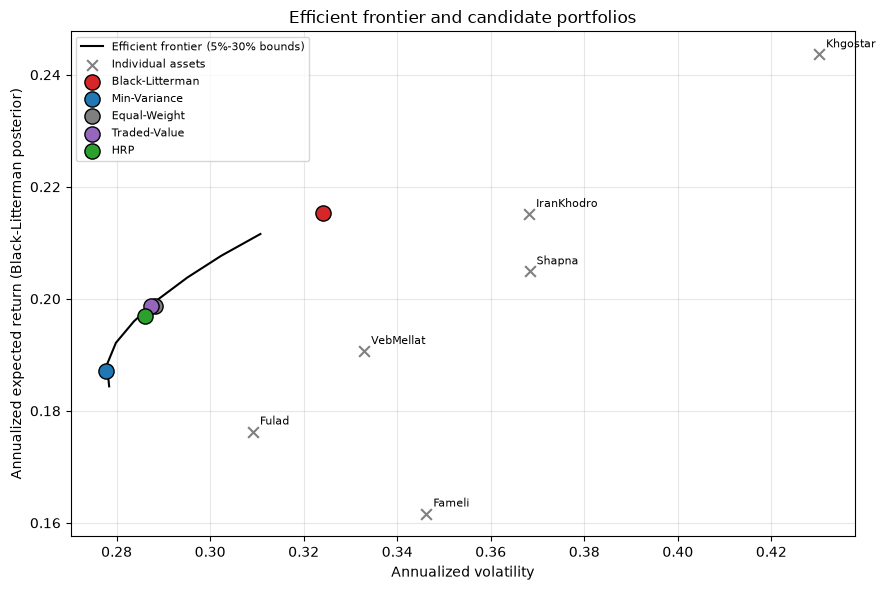

In [9]:
def frontier_vol(target_ret, mu, Sigma, lb, ub):
    n = len(mu)
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
            {'type': 'eq', 'fun': lambda w: w @ mu - target_ret}]
    res = minimize(lambda w: w @ Sigma @ w, np.ones(n) / n, method='SLSQP',
                    bounds=[(lb, ub)] * n, constraints=cons)
    return np.sqrt(res.fun) if res.success else np.nan


targets = np.linspace(Pi_BL.min() * 0.9, Pi_BL.max() * 0.98, 25)
frontier = [frontier_vol(t, Pi_BL, Sigma_ann, W_MIN, W_MAX) for t in targets]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(frontier, targets, '-', color='black', lw=1.5, label='Efficient frontier (5%-30% bounds)')
ax.scatter(vol_ann, Pi_BL, color='gray', marker='x', s=60, label='Individual assets')
for n, x, y in zip(ASSET_NAMES, vol_ann, Pi_BL):
    ax.annotate(n, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)

portfolios = {'Black-Litterman': w_bl, 'Min-Variance': w_minvar, 'Equal-Weight': w_eq,
              'Traded-Value': w_mkt, 'HRP': w_hrp}
colors = {'Black-Litterman': '#d62728', 'Min-Variance': '#1f77b4', 'Equal-Weight': '#7f7f7f',
          'Traded-Value': '#9467bd', 'HRP': '#2ca02c'}
for name, w in portfolios.items():
    ret = w @ Pi_BL
    vol = np.sqrt(w @ Sigma_ann @ w)
    ax.scatter(vol, ret, s=120, color=colors[name], label=name, edgecolor='black', zorder=5)

ax.set_xlabel('Annualized volatility')
ax.set_ylabel('Annualized expected return (Black-Litterman posterior)')
ax.set_title('Efficient frontier and candidate portfolios')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## ۹) جدولِ نهاییِ مقایسه + سهمِ ریسکِ هر دارایی در پورتفویِ منتخب

`Risk_Contribution` نشان می‌دهد چند درصد از **ریسکِ کلِ پورتفو** (نه فقط وزنِ
سرمایه) از هر سهم می‌آید — طبقِ فرمولِ استانداردِ تجزیه‌ی ریسک:
$RC_i = w_i \cdot (\Sigma w)_i / (w^\top \Sigma w)$.

In [10]:
def port_stats(w, mu, Sigma, rf):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return ret, vol, (ret - rf) / vol


rows = []
for name, w in portfolios.items():
    ret, vol, sharpe = port_stats(w, Pi_BL, Sigma_ann, RISK_FREE_RATE)
    row = {'Method': name, **{a: w[i] for i, a in enumerate(ASSET_NAMES)},
           'Sum': round(w.sum(), 6), 'ExpReturn': ret, 'Vol': vol, 'Sharpe': sharpe}
    rows.append(row)
comparison_df = pd.DataFrame(rows)
fmt = {a: '{:.1%}' for a in ASSET_NAMES}
fmt.update({'ExpReturn': '{:.1%}', 'Vol': '{:.1%}', 'Sharpe': '{:.2f}', 'Sum': '{:.4f}'})
display(comparison_df.style.format(fmt))

rc = w_bl * (Sigma_ann @ w_bl) / (w_bl @ Sigma_ann @ w_bl)
risk_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Capital_Weight': w_bl, 'Risk_Contribution': rc})
print("\nپورتفویِ منتخب (Black-Litterman) — سهمِ سرمایه در برابرِ سهمِ ریسک:")
display(risk_df.style.format({'Capital_Weight': '{:.1%}', 'Risk_Contribution': '{:.1%}'}))

,Method,Fameli,Fulad,IranKhodro,Khgostar,Shapna,VebMellat,Sum,ExpReturn,Vol,Sharpe
0,Black-Litterman,5.0%,5.0%,30.0%,30.0%,25.0%,5.0%,1.0000,21.5%,32.4%,0.05
1,Min-Variance,22.9%,28.3%,15.2%,5.0%,5.0%,23.6%,1.0000,18.7%,27.8%,-0.05
2,Equal-Weight,16.7%,16.7%,16.7%,16.7%,16.7%,16.7%,1.0000,19.9%,28.8%,-0.00
3,Traded-Value,12.2%,16.6%,20.6%,13.5%,12.1%,25.1%,1.0000,19.9%,28.7%,-0.00
4,HRP,14.5%,18.2%,20.1%,9.5%,21.8%,15.9%,1.0000,19.7%,28.6%,-0.01



پورتفویِ منتخب (Black-Litterman) — سهمِ سرمایه در برابرِ سهمِ ریسک:


,Asset,Capital_Weight,Risk_Contribution
0,Fameli,5.0%,2.9%
1,Fulad,5.0%,3.4%
2,IranKhodro,30.0%,31.5%
3,Khgostar,30.0%,36.4%
4,Shapna,25.0%,22.2%
5,VebMellat,5.0%,3.5%


## ۱۰) 🎯 پورتفویِ نهاییِ پیشنهادی

پورتفویِ **Black-Litterman با محدودیتِ وزن (۵٪ تا ۳۰٪)** به‌عنوانِ پورتفویِ
نهایی پیشنهاد می‌شود — چون تنها روشی است که هم دیدگاه‌های واقعیِ مدلِ Ensemble
(بخشِ ۴) را وارد می‌کند، هم با استفاده از Ledoit-Wolf و محدودیتِ وزن، در برابرِ
مشکلِ شناخته‌شده‌ی تمرکزِ افراطیِ Markowitz محافظت‌شده است.

مجموعِ وزن‌ها = 1.000000



,Asset,Weight (%)
2,IranKhodro,30.0
3,Khgostar,30.0
4,Shapna,25.0
0,Fameli,5.0
1,Fulad,5.0
5,VebMellat,5.0


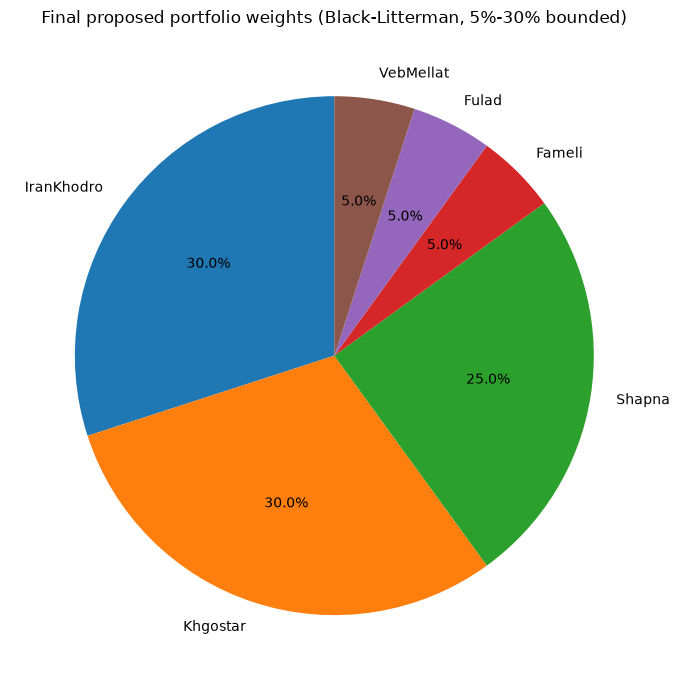

In [11]:
final_df = pd.DataFrame({'Asset': ASSET_NAMES, 'Weight': w_bl}).sort_values('Weight', ascending=False)
final_df['Weight_pct'] = (final_df['Weight'] * 100).round(2)
print(f"مجموعِ وزن‌ها = {final_df['Weight'].sum():.6f}\n")
display(final_df[['Asset', 'Weight_pct']].rename(columns={'Weight_pct': 'Weight (%)'}))

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(final_df['Weight'], labels=final_df['Asset'], autopct='%1.1f%%', startangle=90,
       colors=plt.cm.tab10.colors[:len(final_df)])
ax.set_title('Final proposed portfolio weights (Black-Litterman, 5%-30% bounded)')
plt.tight_layout()
plt.show()

## ۱۱) محدودیت‌ها و صداقتِ علمی

- **بازدهِ موردانتظار (Views) از نوت‌بوکِ پیش‌بینی می‌آید که خودش صادقانه نشان
  داد قدرتِ پیش‌بینیِ محدودی دارد** (اکثرِ مدل‌ها از Naive بهتر نشدند). به‌همین
  دلیل، معماریِ Black-Litterman عمداً انتخاب شد: چون این ضعف را «کتمان» نمی‌کند،
  بلکه با $\Omega$ (برگرفته از همان RMSEِ صادقانه) به‌طورِ ریاضی آن را در وزنِ
  دیدگاه دخالت می‌دهد — دیدگاهِ نامطمئن‌تر، تأثیرِ کمتری روی پورتفوی نهایی دارد.
- **کوواریانس روی ۲ سالِ اخیر برآورد شده**، نه کلِ تاریخچه — چون رژیمِ نوسان/
  تورمِ بازارِ تهران در بازه‌های مختلف بسیار متفاوت بوده؛ این یک انتخابِ آگاهانه
  است، نه محدودیت.
- **بدونِ فروشِ استقراضی (Short Selling)** فرض شده — منطبق با محدودیت‌های
  واقعیِ بازارِ ایران و سازگار با هدفِ کاورد کال (باید سهم را در اختیار داشت).
- محدودیتِ ۵٪-۳۰٪ یک انتخابِ رایجِ صنعتی است، نه نتیجه‌ی ریاضی — با نرم‌افزار/
  سیاستِ متفاوت می‌تواند تغییر کند؛ در بخشِ ۶ می‌بینید بدونِ این محدودیت،
  نتیجه چقدر ناپایدار می‌شد.
- این پورتفو صرفاً بر اساسِ ریسک/بازدهِ آماری ساخته شده؛ هزینه‌ی معاملات،
  محدودیت‌های نقدشوندگی، و مالیات در نظر گرفته نشده‌اند.

## ۱۲) ذخیره‌ی خروجی

In [12]:
OUT_DIR = DATA_DIR
final_df[['Asset', 'Weight']].to_csv(OUT_DIR + 'portfolio_weights_black_litterman.csv', index=False)
comparison_df.to_csv(OUT_DIR + 'portfolio_methods_comparison.csv', index=False)
print("✅ ذخیره شد: portfolio_weights_black_litterman.csv, portfolio_methods_comparison.csv")

✅ ذخیره شد: portfolio_weights_black_litterman.csv, portfolio_methods_comparison.csv
